In [2]:
import math
import random
import pandas as pd
import numpy as np
import scipy as sp
from scipy import stats
import itertools
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec
from matplotlib import cm
import matplotlib 
%matplotlib inline

In [3]:
! pwd

/Users/alyulina/Projects/Cancer/Code


In [4]:
# NOTE THAT THIS CODE USES OLD DATA -- NEED TO RERUN THE BARCODE INFERENCE PIPELINE

In [69]:
# data from https://docs.google.com/spreadsheets/d/100QgXtkE5FHj-EFaa64HkjYu8EddSB07/edit#gid=1566829729

# cell line IDs w/o spike-ins and mt4-2D
clIDs = ['AAGG', 'ACAC', 'ACCT', 'ACGA', 'ACTG', 'AGAG', 'AGCA', 'AGGT', 'AGTC', 'ATCG', 'ATGC', 'CAAC', 'CACT', 'CAGA', 'CATG', 'CCAA', 'CCTT', 'CGAT', 'CGTA', 'CTGT', 'CTTC', 'GAAG', 'GCAT', 'GCTA', 'GGAA', 'GGTT', 'GTAC', 'GTGA', 'GTTG', 'TCCA', 'TGAC', 'TTCC', 'TTGG']

# cell lines w/o spike-ins and mt4-2D; added numbers (1 and 2) to cell lines w/ identical names
cell_lines = ['7160c2', 'FC1199', '6694c2', '7160c5', 'BF857', 'BF1987', 'Panc2', '0688_M', 'FC1245-1', 'BF4326-1', 'BF2117', '6419c5', 'BF4326-2', 'UN-KPC_960-1', '0755_Pancreas', 'BF1836', 'BF2014', 'BF5960', '6499c4', '6422c5', 'FC1245-2', 'KPC_cell_line', 'UN-KPC_960-2', 'BF2153', 'UN-KC-6141', 'mT3-2D', 'mT5-2D', '0764_Pancreas', '6421c2', '0755_Ascites', '2838c3', 'FC1242', 'UN-KPC_961']

clID_dict = dict(zip(clIDs, cell_lines))
cell_line_dict = dict(zip(cell_lines, clIDs))

# samples sequenced in the second run
samples_3w = ['SK1_' + '{:0.0f}'.format(i) for i in range(25, 45)]
samples_pre_inj = ['SK1_' + '{:0.0f}'.format(i) for i in [61, 62, 63]]


In [70]:
sample_clID_counts_3w = [] # a list of dictionaries for each sample

for i, sample in enumerate(samples_3w):
    
    sample_clID_counts_3w.append({}) # initiating a dictionary for each sample
    for j in clIDs:
        sample_clID_counts_3w[i][j] = [] # initiating lists for counts for each cell line within a sample
    
    n_sample_spikes_coverage = [0, 0, 0]
    n_sample_cancer_cells_coverage = 0
    for line in open('../Data/bc_counts/novogene_01.09.2023_X202SC22123847-Z01-F001/' + sample + '_merged_clIDs_bc_clusters_counts.txt', 'r'):
        clID_bc, count = line.strip('\n').split()
        #print(clID_bc, count)
        
        # IGNORING SPIKE-INS
        if int(count) < 2 or clID_bc[:4] not in clIDs: # only adding barcodes with at least two reads
            continue
            
        sample_clID_counts_3w[i][clID_bc[:4]].append([clID_bc[5:], int(count)])
    

In [71]:
sample_clID_counts_pre_inj = [] # a list of dictionaries for each sample

for i, sample in enumerate(samples_pre_inj):
    
    sample_clID_counts_pre_inj.append({}) # initiating a dictionary for each sample
    for j in clIDs:
        sample_clID_counts_pre_inj[i][j] = [] # initiating lists for counts for each cell line within a sample
    
    n_sample_spikes_coverage = [0, 0, 0]
    n_sample_cancer_cells_coverage = 0
    for line in open('../Data/bc_counts/novogene_02.22.2023_X202SC23012558-Z01-F001/' + sample + '_merged_clIDs_bc_clusters_counts.txt', 'r'):
        clID_bc, count = line.strip('\n').split()
        # print(clID_bc, count)
        
        # IGNORING SPIKE-INS
        if int(count) < 2 or clID_bc[:4] not in clIDs: # only adding barcodes with at least two reads
            continue
            
        sample_clID_counts_pre_inj[i][clID_bc[:4]].append([clID_bc[5:], int(count)])
    

In [72]:
# cancer reads per sample - this is ~coverage
n_reads_cancer_cells_3w = {}
for i, sample in enumerate(samples_3w):
    
    counts = 0
    for j in clIDs:
        if clID_dict.get(j)[:5] != 'Spike' and clID_dict.get(j) != 'mT4-2D': # excluding spike-ins and mT4-2D
            counts += sum([x[-1] for x in sample_clID_counts_3w[i][j]])
            
    n_reads_cancer_cells_3w[sample] = counts     

In [73]:
# cancer reads per sample
n_reads_cancer_cells_pre_inj = {}
for i, sample in enumerate(samples_pre_inj):
    
    counts = 0
    for j in clIDs:
        if clID_dict.get(j)[:5] != 'Spike' and clID_dict.get(j) != 'mT4-2D': # excluding spike-ins and mT4-2D
            counts += sum([x[-1] for x in sample_clID_counts_pre_inj[i][j]])
        #else:
        #    print(clID_dict.get(j))
            
    n_reads_cancer_cells_pre_inj[sample] = counts

In [74]:
# a dictionary with barcode freqs for each cell line for each sample: 
# {sample:{clID:[freq]}}

bc_freqs_3w_f1 = {}
for i, sample in enumerate(samples_3w):
    bc_freqs_3w_f1[sample] = {}
    
    norm = n_reads_cancer_cells_3w[sample]
    
    for j in clIDs:
        freqs = [x[-1] / norm for x in sample_clID_counts_3w[i][j]]
        bc_freqs_3w_f1[sample][j] = freqs

In [75]:
# pooling across mice:
bc_freqs_3w_f1_pooled = {}

for j in clIDs:
    bc_freqs_3w_f1_pooled[j] = []
    
    for i, sample in enumerate(samples_3w):
        bc_freqs_3w_f1_pooled[j].extend(bc_freqs_3w_f1[sample][j])


In [76]:
bc_freqs_3w_f1_renorm = {} # normalized not by total coverage, but by total read count within a cell line

for i, sample in enumerate(samples_3w):
    bc_freqs_3w_f1_renorm[sample] = {}
    
    for j in clIDs:
        counts = [x[-1] for x in sample_clID_counts_3w[i][j]]
        norm = sum(counts)
        freqs = [x / norm for x in counts]
        bc_freqs_3w_f1_renorm[sample][j] = freqs

In [77]:
# pooling across mice:
bc_freqs_3w_f1_renorm_pooled = {}

for j in clIDs:
    bc_freqs_3w_f1_renorm_pooled[j] = []
    
    for i, sample in enumerate(samples_3w):
        bc_freqs_3w_f1_renorm_pooled[j].extend(bc_freqs_3w_f1_renorm[sample][j])


In [78]:
# avg frac of reads across mice:
avg_read_frac_3w_f1 = {}

for j in clIDs:
    
    fracs = []
    for i, sample in enumerate(samples_3w):
        norm = n_reads_cancer_cells_3w[sample]
        fracs.append(sum([x[-1] for x in sample_clID_counts_3w[i][j]]) / norm)
        
    #print(fracs)
    
    avg_read_frac_3w_f1[j] = np.mean(fracs)

In [79]:
# avg frac of reads pre-inj:
avg_read_frac_pre_inj = {}

for j in clIDs:
    
    fracs = []
    for i, sample in enumerate(samples_pre_inj):
        norm = n_reads_cancer_cells_pre_inj[sample]
        fracs.append(sum([x[-1] for x in sample_clID_counts_pre_inj[i][j]]) / norm)
        
    #print(fracs)
    
    avg_read_frac_pre_inj[j] = np.mean(fracs)

In [109]:
# avg frac of reads across mice relative pre-inj:
relative_avg_read_frac = []

for j in clIDs: 
    relative_avg_read_frac.append([j, avg_read_frac_3w_f1[j] / avg_read_frac_pre_inj[j]])
   

In [110]:
clIDs_ordered = [x[0] for x in sorted(relative_avg_read_frac, key = lambda x: x[-1], reverse=True)]

In [113]:
viridis = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=len(clIDs_ordered)), 
                                       cmap=plt.get_cmap('viridis'))

In [131]:
#! mkdir Plots/distr

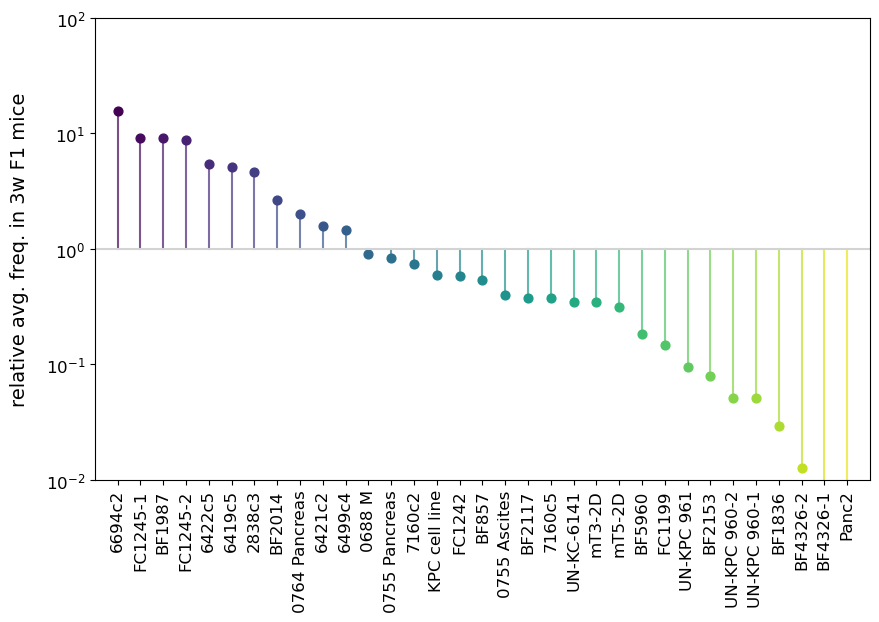

In [132]:
plt.figure(figsize=(10, 6));

for c, clID in enumerate(clIDs_ordered):
    y = dict(relative_avg_read_frac)[clID]
    plt.scatter(c, y, color=viridis.to_rgba(c), s=40)
    plt.plot([c, c], [1, y], color=viridis.to_rgba(c), alpha=0.7)
    
plt.axhline(1, 0, 1, c='#d3d3d3')
    
plt.yscale('log')
plt.minorticks_off();

plt.ylim(1e-2, 1e2);
plt.xlim(-1, 33);

plt.xticks(range(len(clIDs_ordered)), [clID_dict[x].replace('_', ' ') for x in clIDs_ordered], rotation=90, size=12);
plt.yticks(size=12);

plt.ylabel('relative avg. freq. in 3w F1 mice', fontsize=14, labelpad=12);

#plt.savefig('Plots/distr/relative_avg._freq._in_3w_F1_mice.png', dpi=300, bbox_inches='tight')

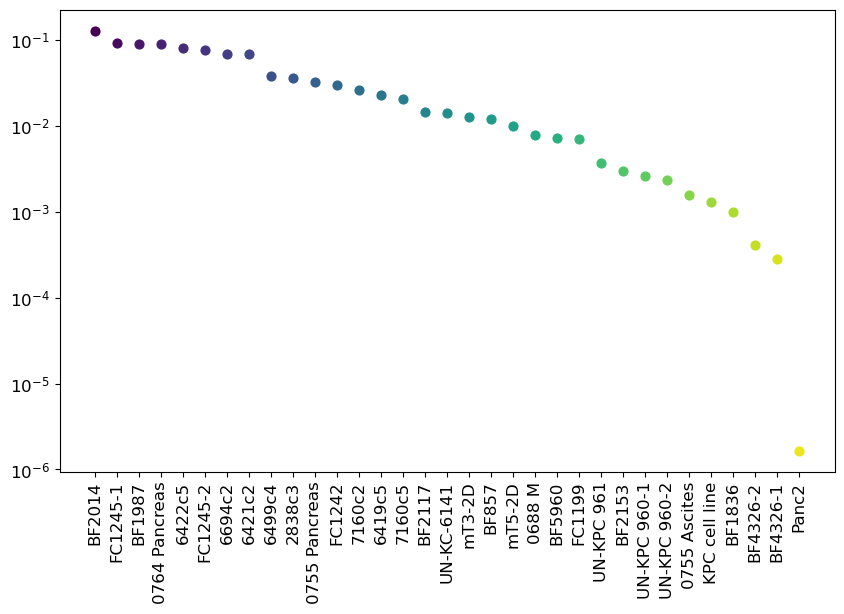

In [122]:
clIDs_ordered_not_normalized = [x[0] for x in sorted(avg_read_frac_3w_f1.items(), key = lambda x: x[-1], reverse=True)]
viridis_alt = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=len(clIDs_ordered_not_normalized)), 
                                       cmap=plt.get_cmap('viridis'))


plt.figure(figsize=(10, 6));

for c, clID in enumerate(clIDs_ordered_not_normalized):
    y = avg_read_frac_3w_f1[clID]
    plt.scatter(c, y, color=viridis_alt.to_rgba(c), s=40)
    #plt.plot([c, c], [1, y], color=viridis_alt.to_rgba(c), alpha=0.7)
    
#plt.axhline(1, 0, 1, c='#d3d3d3')
    
plt.yscale('log')
plt.minorticks_off();

#plt.ylim(1e-2, 1e2);
#plt.xlim(-1, 33);

plt.xticks(range(len(clIDs_ordered)), [clID_dict[x].replace('_', ' ') for x in clIDs_ordered_not_normalized], rotation=90, size=12);
plt.yticks(size=12);

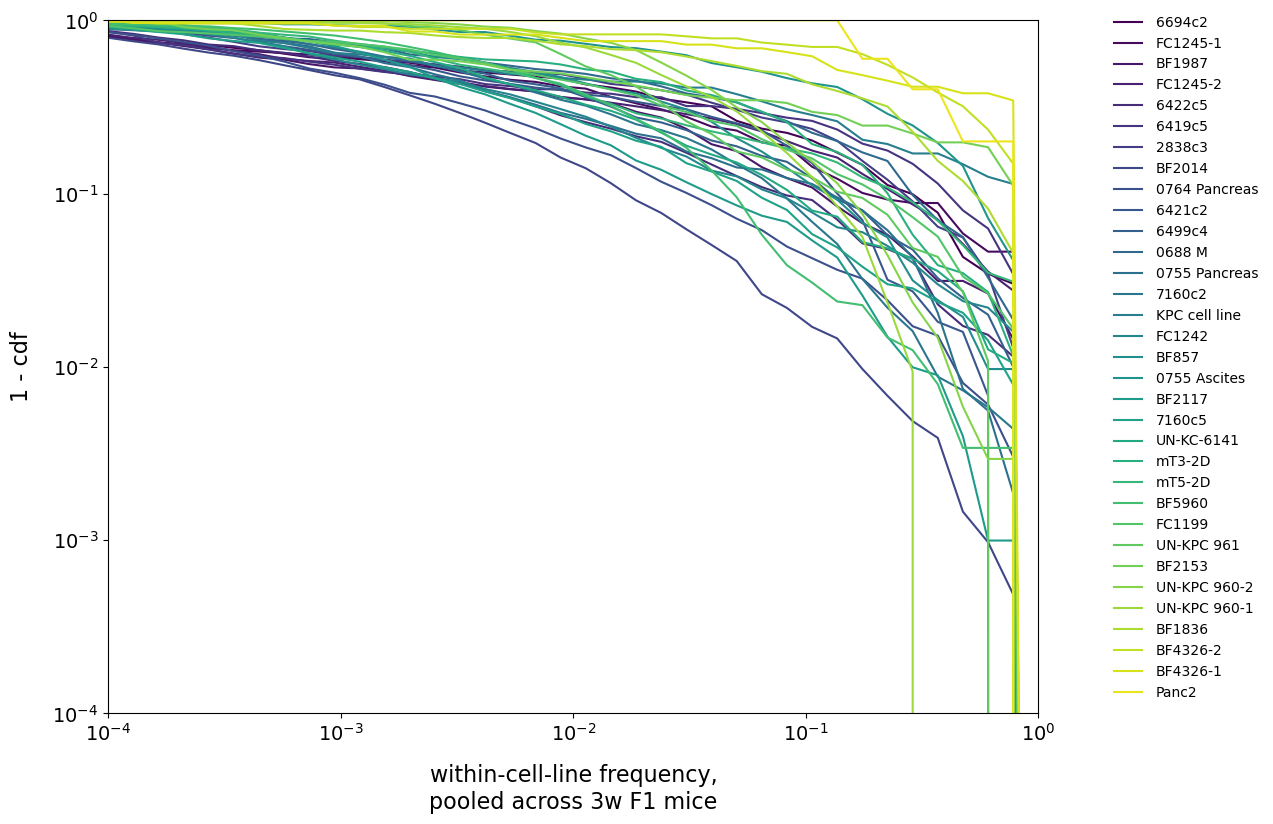

In [162]:
plt.figure(figsize=(12, 9));

sample_id = 0

for c, clID in enumerate(clIDs_ordered):
    freqs = bc_freqs_3w_f1_renorm_pooled[clID]
    count, bins_count = np.histogram(freqs, bins=np.logspace(np.log(5e-3),np.log(1.0), 50))
    pdf = count / sum(count)
    cdf = np.cumsum(pdf)
    plt.plot(bins_count[1:], 1 - cdf, color=viridis.to_rgba(c), label=clID_dict[clID].replace('_', ' '))
    
# adding neg binomial
#negbin = np.random.negative_binomial(1, 0.5, size=1000)
#freqs = negbin / sum(negbin)
#count, bins_count = np.histogram(freqs, bins=50)
#pdf = count / sum(count)
#cdf = np.cumsum(pdf)
#plt.plot(bins_count[1:], 1 - cdf, color='red', label=clID_dict[clID].replace('_', ' '))
    
plt.legend(frameon=False, ncol=1, handletextpad=1, loc='upper right', bbox_to_anchor=(1.25, 1.025)); 

plt.xticks(size=14)
plt.yticks(size=14)


plt.yscale('log')
plt.xscale('log')
plt.minorticks_off();

plt.xlim(1e-4, 1e0);
plt.ylim(1e-4, 1e0);

plt.xlabel('within-cell-line frequency,\npooled across 3w F1 mice', fontsize=16, labelpad=14);
plt.ylabel('1 - cdf', fontsize=16, labelpad=14);


#plt.savefig('Plots/distr/bc_distr_3w_F1_mice.png', dpi=300, bbox_inches='tight')

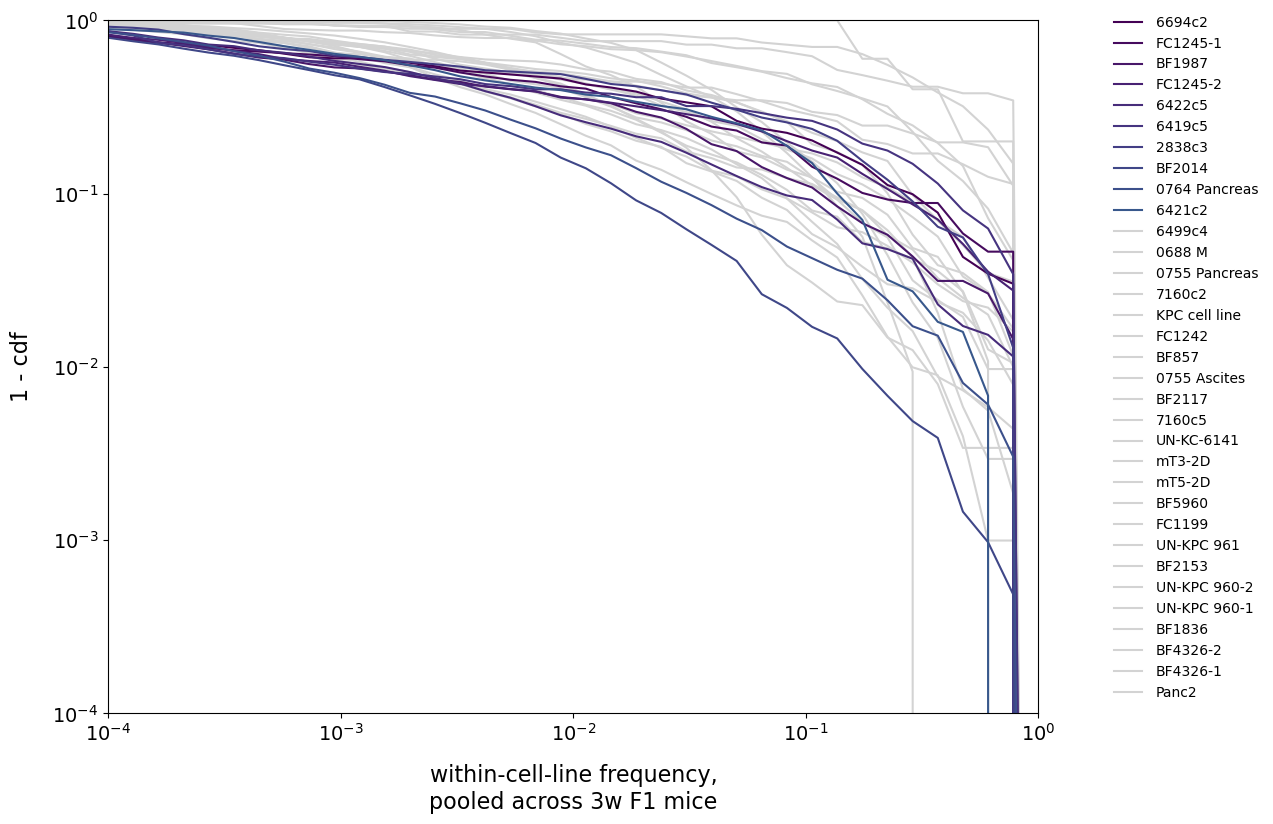

In [174]:
plt.figure(figsize=(12, 9));

sample_id = 0

for c, clID in enumerate(clIDs_ordered):
    if c > 9:
        color = "#d3d3d3"
        z = -1
    else:
        color = viridis.to_rgba(c)
        z = 1
    freqs = bc_freqs_3w_f1_renorm_pooled[clID]
    count, bins_count = np.histogram(freqs, bins=np.logspace(np.log(5e-3),np.log(1.0), 50))
    pdf = count / sum(count)
    cdf = np.cumsum(pdf)
    plt.plot(bins_count[1:], 1 - cdf, color=color, zorder=z, label=clID_dict[clID].replace('_', ' '))
    
# adding neg binomial
#negbin = np.random.negative_binomial(1, 0.5, size=1000)
#freqs = negbin / sum(negbin)
#count, bins_count = np.histogram(freqs, bins=50)
#pdf = count / sum(count)
#cdf = np.cumsum(pdf)
#plt.plot(bins_count[1:], 1 - cdf, color='red', label=clID_dict[clID].replace('_', ' '))
    
plt.legend(frameon=False, ncol=1, handletextpad=1, loc='upper right', bbox_to_anchor=(1.25, 1.025)); 

plt.xticks(size=14)
plt.yticks(size=14)


plt.yscale('log')
plt.xscale('log')
plt.minorticks_off();

plt.xlim(1e-4, 1e0);
plt.ylim(1e-4, 1e0);

plt.xlabel('within-cell-line frequency,\npooled across 3w F1 mice', fontsize=16, labelpad=14);
plt.ylabel('1 - cdf', fontsize=16, labelpad=14);


#plt.savefig('Plots/distr/bc_distr_3w_F1_mice_larger_tumors.png', dpi=300, bbox_inches='tight')

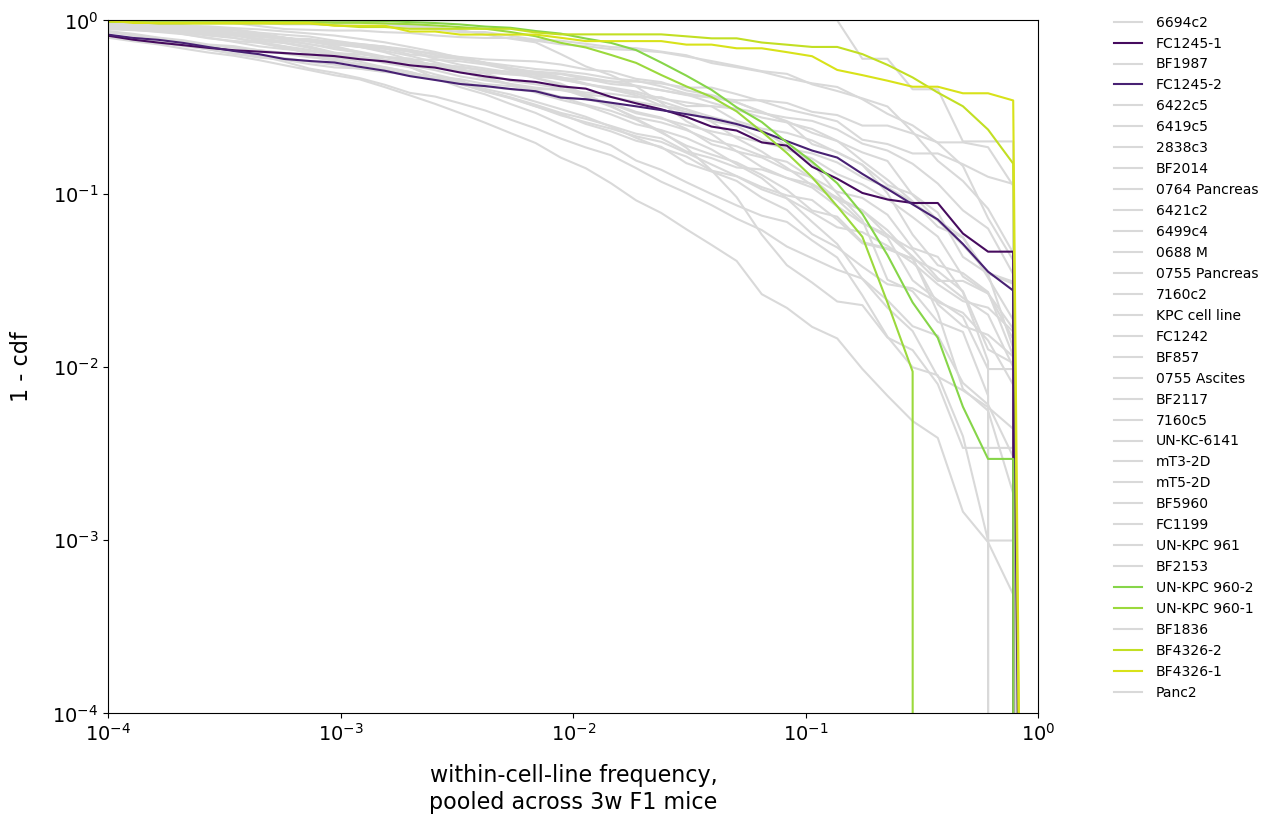

In [163]:
plt.figure(figsize=(12, 9));

sample_id = 0

for c, clID in enumerate(clIDs_ordered):
    
    if clID_dict[clID] not in ['FC1245-1', 'FC1245-2', 'UN-KPC_960-1', 'UN-KPC_960-2', 'BF4326-1', 'BF4326-2']:
        color = '#d9d9d9'
        z = -1
    else:
        color = viridis.to_rgba(c)
        z = 1
    freqs = bc_freqs_3w_f1_renorm_pooled[clID]
    count, bins_count = np.histogram(freqs, bins=np.logspace(np.log(5e-3),np.log(1.0), 50))
    pdf = count / sum(count)
    cdf = np.cumsum(pdf)
    plt.plot(bins_count[1:], 1 - cdf, color=color, zorder=z, label=clID_dict[clID].replace('_', ' '))
    
# adding neg binomial
#negbin = np.random.negative_binomial(1, 0.5, size=1000)
#freqs = negbin / sum(negbin)
#count, bins_count = np.histogram(freqs, bins=50)
#pdf = count / sum(count)
#cdf = np.cumsum(pdf)
#plt.plot(bins_count[1:], 1 - cdf, color='red', label=clID_dict[clID].replace('_', ' '))
    
plt.legend(frameon=False, ncol=1, handletextpad=1, loc='upper right', bbox_to_anchor=(1.25, 1.025)); 

plt.xticks(size=14)
plt.yticks(size=14)


plt.yscale('log')
plt.xscale('log')
plt.minorticks_off();

plt.xlim(1e-4, 1e0);
plt.ylim(1e-4, 1e0);

plt.xlabel('within-cell-line frequency,\npooled across 3w F1 mice', fontsize=16, labelpad=14);
plt.ylabel('1 - cdf', fontsize=16, labelpad=14);


#plt.savefig('Plots/distr/bc_distr_3w_F1_mice_grey.png', dpi=300, bbox_inches='tight')

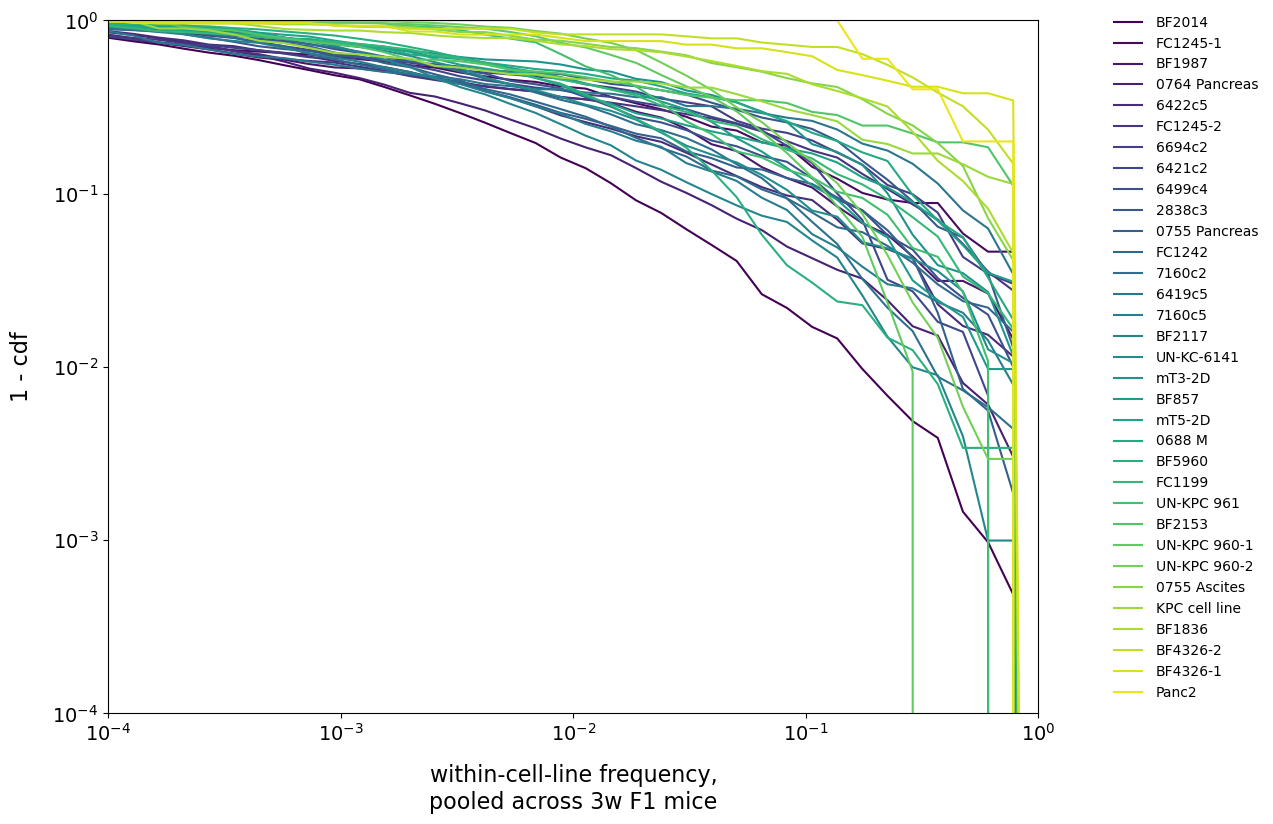

In [165]:
plt.figure(figsize=(12, 9));

sample_id = 0

for c, clID in enumerate(clIDs_ordered_not_normalized):
    #if clID_dict[clID] not in ['FC1245-1', 'FC1245-2', 'UN-KPC_960-1', 'UN-KPC_960-2', 'BF4326-1', 'BF4326-2']:
    #    continue
    freqs = bc_freqs_3w_f1_renorm_pooled[clID]
    count, bins_count = np.histogram(freqs, bins=np.logspace(np.log(5e-3),np.log(1.0), 50))
    pdf = count / sum(count)
    cdf = np.cumsum(pdf)
    plt.plot(bins_count[1:], 1 - cdf, color=viridis_alt.to_rgba(c), label=clID_dict[clID].replace('_', ' '))
    
# adding neg binomial
#negbin = np.random.negative_binomial(1, 0.5, size=1000)
#freqs = negbin / sum(negbin)
#count, bins_count = np.histogram(freqs, bins=50)
#pdf = count / sum(count)
#cdf = np.cumsum(pdf)
#plt.plot(bins_count[1:], 1 - cdf, color='red', label=clID_dict[clID].replace('_', ' '))
    
plt.legend(frameon=False, ncol=1, handletextpad=1, loc='upper right', bbox_to_anchor=(1.25, 1.025)); 

plt.xticks(size=14)
plt.yticks(size=14)


plt.yscale('log')
plt.xscale('log')
plt.minorticks_off();

plt.xlim(1e-4, 1e0);
plt.ylim(1e-4, 1e0);

plt.xlabel('within-cell-line frequency,\npooled across 3w F1 mice', fontsize=16, labelpad=14);
plt.ylabel('1 - cdf', fontsize=16, labelpad=14);


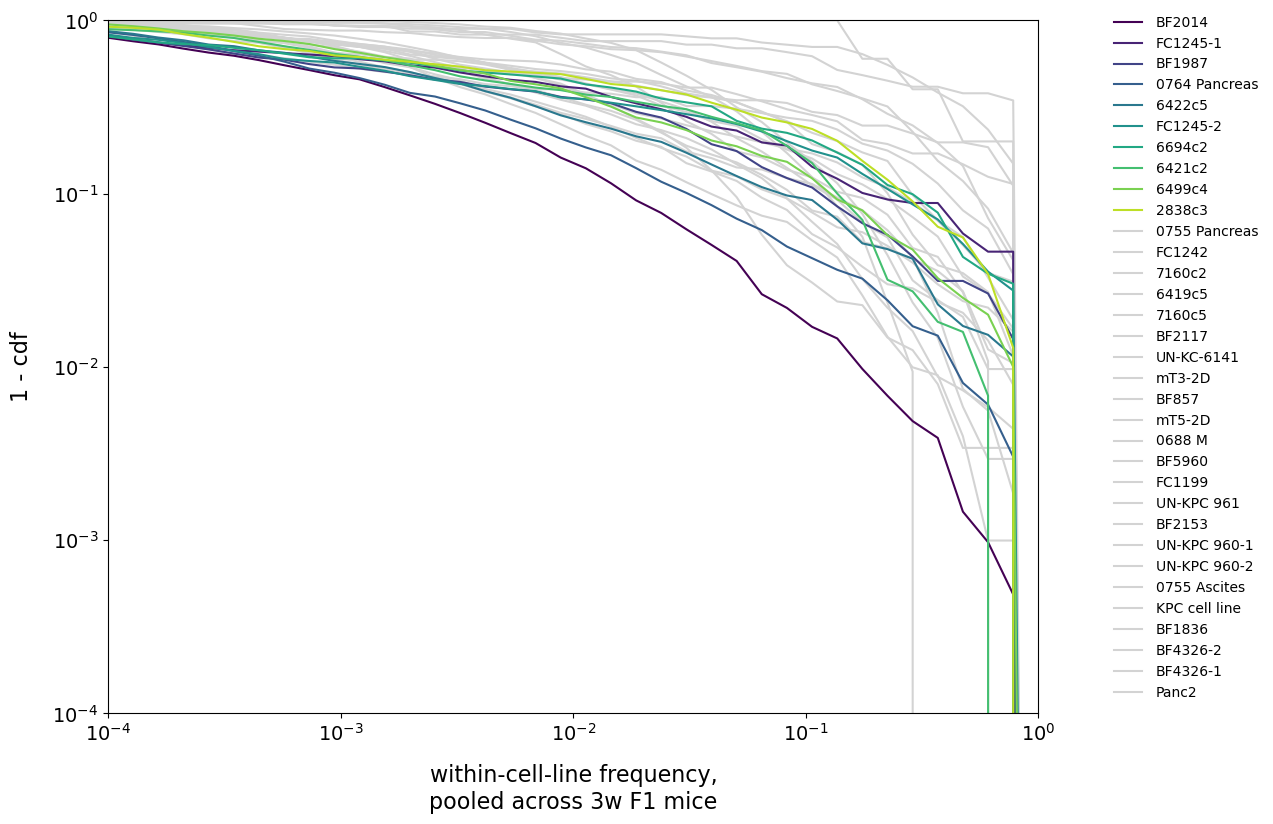

In [183]:
plt.figure(figsize=(12, 9));

viridis_alt_renorm = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=10), 
                                       cmap=plt.get_cmap('viridis'))


for c, clID in enumerate(clIDs_ordered_not_normalized):
    if c > 9:
        color = "#d3d3d3"
        z = -1
    else:
        color = viridis_alt_renorm.to_rgba(c)
        z = 1
    freqs = bc_freqs_3w_f1_renorm_pooled[clID]
    count, bins_count = np.histogram(freqs, bins=np.logspace(np.log(5e-3),np.log(1), 50))
    pdf = count / sum(count)
    cdf = np.cumsum(pdf)
    plt.plot(bins_count[1:], 1 - cdf, color=color, zorder=z, label=clID_dict[clID].replace('_', ' '))
    
# adding neg binomial
#negbin = np.random.negative_binomial(1, 0.5, size=1000)
#freqs = negbin / sum(negbin)
#count, bins_count = np.histogram(freqs, bins=50)
#pdf = count / sum(count)
#cdf = np.cumsum(pdf)
#plt.plot(bins_count[1:], 1 - cdf, color='red', label=clID_dict[clID].replace('_', ' '))
    
plt.legend(frameon=False, ncol=1, handletextpad=1, loc='upper right', bbox_to_anchor=(1.25, 1.025)); 

plt.xticks(size=14)
plt.yticks(size=14)


plt.yscale('log')
plt.xscale('log')
plt.minorticks_off();

plt.xlim(1e-4, 1e0);
plt.ylim(1e-4, 1e0);

plt.xlabel('within-cell-line frequency,\npooled across 3w F1 mice', fontsize=16, labelpad=14);
plt.ylabel('1 - cdf', fontsize=16, labelpad=14);


0.35781861870956444


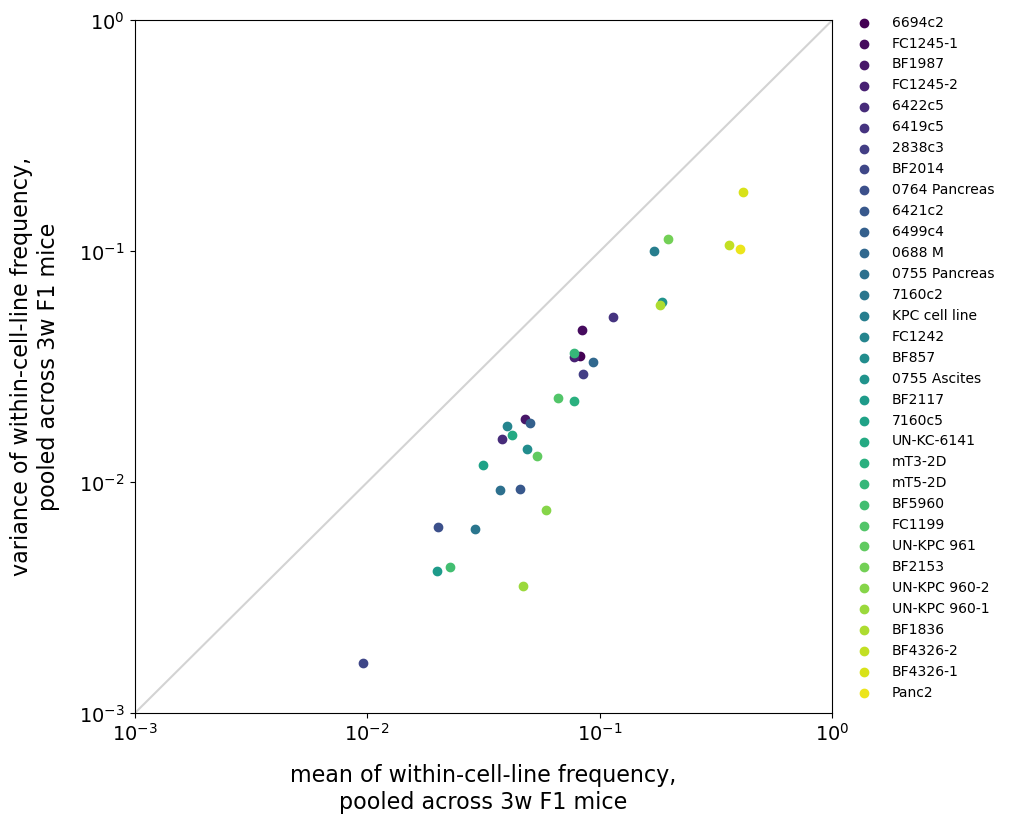

In [170]:
# mean vs var 
plt.figure(figsize=(9, 9));

x = []
y = []
for c, clID in enumerate(clIDs_ordered):
    freqs = bc_freqs_3w_f1_renorm_pooled[clID]
    mean = np.mean(freqs)
    var = np.var(freqs)
    x.append(mean)
    y.append(var)
    plt.scatter(mean, var, color=viridis.to_rgba(c), label=clID_dict[clID].replace('_', ' '))
    
plt.plot([1e-5, 1], [1e-5, 1], c='#d3d3d3')
    
slope, intercept, r, p, se = sp.stats.linregress(x, y)
#plt.plot([1e-5, 1], [slope * 1e-5, slope * 1], c='red')
print(slope) 
    
plt.legend(frameon=False, ncol=1, handletextpad=1, loc='upper right', bbox_to_anchor=(1.25, 1.025)); 

plt.xticks(size=14)
plt.yticks(size=14)


plt.yscale('log')
plt.xscale('log')
plt.minorticks_off();

plt.xlim(1e-3, 1e0);
plt.ylim(1e-3, 1e0);

plt.xlabel('mean of within-cell-line frequency,\npooled across 3w F1 mice', fontsize=16, labelpad=14);
plt.ylabel('variance of within-cell-line frequency,\npooled across 3w F1 mice', fontsize=16, labelpad=14);


#plt.savefig('Plots/distr/mean_var_3w_F1_mice.png', dpi=300, bbox_inches='tight')

In [180]:
np.logspace(np.log(5e-3),np.log(1.01), 50)

array([5.03132803e-06, 6.45675975e-06, 8.28603228e-06, 1.06335583e-05,
       1.36461647e-05, 1.75122764e-05, 2.24737009e-05, 2.88407527e-05,
       3.70116617e-05, 4.74974810e-05, 6.09540507e-05, 7.82230176e-05,
       1.00384477e-04, 1.28824526e-04, 1.65321961e-04, 2.12159528e-04,
       2.72266704e-04, 3.49402919e-04, 4.48392688e-04, 5.75427371e-04,
       7.38452406e-04, 9.47664264e-04, 1.21614819e-03, 1.56069663e-03,
       2.00285950e-03, 2.57029209e-03, 3.29848469e-03, 4.23298244e-03,
       5.43223389e-03, 6.97124674e-03, 8.94627921e-03, 1.14808606e-02,
       1.47335172e-02, 1.89076881e-02, 2.42644484e-02, 3.11388391e-02,
       3.99608218e-02, 5.12821713e-02, 6.58109862e-02, 8.44559775e-02,
       1.08383304e-01, 1.39089511e-01, 1.78495131e-01, 2.29064806e-01,
       2.93961437e-01, 3.77244013e-01, 4.84121477e-01, 6.21278527e-01,
       7.97293708e-01, 1.02317597e+00])